# Ejercicio 1 — Redes neuronales para NAND y XOR

Se desarrollan dos redes neuronales artificiales con **dos capas ocultas**, siguiendo la estructura de la guía:

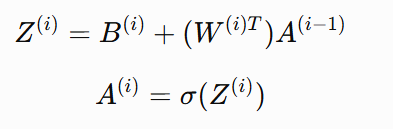\[


La red utilizada en ambos casos tiene:

- 2 entradas: \(x1,x2\)
- 1.ª capa oculta: 3 neuronas
- 2.ª capa oculta: 3 neuronas
- 1 neurona de salida

Por tanto, la topología es **2–3–3–1**.

El entrenamiento se realiza mediante **backpropagation** y descenso del gradiente.

## 1. Datos de entrada

Las cuatro combinaciones posibles de dos entradas binarias son:

| \(x_1\) | \(x_2\) |
|---|---|
| 0 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 1 |

Los rótulos esperados son:

**NAND:** \(Y=[1,1,1,0]\)

**XOR:** \(Y=[0,1,1,0]\)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Cada columna representa un ejemplo de entrenamiento
X = np.array([
    [0, 0, 1, 1],   # x1
    [0, 1, 0, 1]    # x2
], dtype=float)

Y_NAND = np.array([[1, 1, 1, 0]], dtype=float)
Y_XOR  = np.array([[0, 1, 1, 0]], dtype=float)

print("X:")
print(X)
print("\nY NAND:", Y_NAND)
print("Y XOR :", Y_XOR)

X:
[[0. 0. 1. 1.]
 [0. 1. 0. 1.]]

Y NAND: [[1. 1. 1. 0.]]
Y XOR : [[0. 1. 1. 0.]]


## 2. Función de activación

Se usa la función sigmoide:

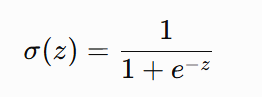

y su derivada:

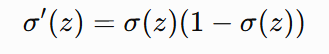

La derivada es necesaria para el algoritmo de retropropagación.

In [3]:
def sig(z):
    return 1 / (1 + np.exp(-z))

def dsig(a):
    # Si a = sig(z), entonces sig'(z) = a(1-a)
    return a * (1 - a)

## 3. Inicialización de la red

Los pesos y sesgos se inicializan con valores pequeños entre 0 y 0.5.

Las dimensiones son:

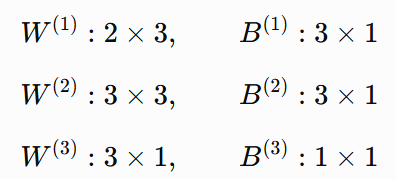

In [5]:
def inicializar_red(semilla=42):
    rng = np.random.default_rng(semilla)

    W1 = rng.uniform(0, 0.5, (2, 3))
    B1 = rng.uniform(0, 0.5, (3, 1))

    W2 = rng.uniform(0, 0.5, (3, 3))
    B2 = rng.uniform(0, 0.5, (3, 1))

    W3 = rng.uniform(0, 0.5, (3, 1))
    B3 = rng.uniform(0, 0.5, (1, 1))

    return W1, B1, W2, B2, W3, B3

## 4. Propagación hacia adelante

Para cada capa se calcula primero Z y después se aplica la sigmoide:

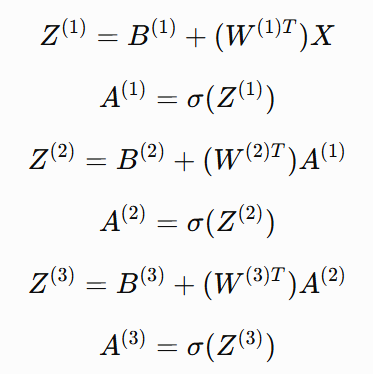

La salida de la red es A^3.

In [7]:
def propaga(X, W1, B1, W2, B2, W3, B3):

    Z1 = B1 + W1.T @ X
    A1 = sig(Z1)

    Z2 = B2 + W2.T @ A1
    A2 = sig(Z2)

    Z3 = B3 + W3.T @ A2
    A3 = sig(Z3)

    return Z1, A1, Z2, A2, Z3, A3

## 5. Retropropagación

Se calcula primero el error:

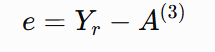

Luego el error se propaga desde la salida hacia las capas anteriores.

Para la salida:

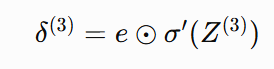

Para la segunda capa oculta:

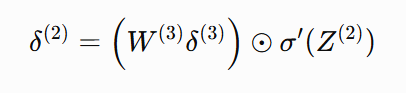

Para la primera capa oculta:

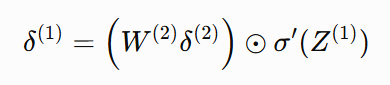

Finalmente se actualizan los pesos y sesgos usando la tasa de aprendizaje n.

In [8]:
def entrenar(X, Yr, epocas=50000, eta=0.5, semilla=42):

    W1, B1, W2, B2, W3, B3 = inicializar_red(semilla)

    m = X.shape[1]
    historial = []

    for epoca in range(epocas):

        # ----- PROPAGACIÓN -----
        Z1, A1, Z2, A2, Z3, A3 = propaga(
            X, W1, B1, W2, B2, W3, B3
        )

        # Error y función de pérdida
        error = Yr - A3
        perdida = np.mean(0.5 * error**2)

        if epoca % 500 == 0:
            historial.append(perdida)

        # ----- BACKPROPAGATION -----
        delta3 = error * dsig(A3)
        delta2 = (W3 @ delta3) * dsig(A2)
        delta1 = (W2 @ delta2) * dsig(A1)

        # ----- ACTUALIZACIÓN DE PESOS -----
        W3 += eta * (A2 @ delta3.T) / m
        B3 += eta * np.mean(delta3, axis=1, keepdims=True)

        W2 += eta * (A1 @ delta2.T) / m
        B2 += eta * np.mean(delta2, axis=1, keepdims=True)

        W1 += eta * (X @ delta1.T) / m
        B1 += eta * np.mean(delta1, axis=1, keepdims=True)

    parametros = (W1, B1, W2, B2, W3, B3)

    # Salida final
    _, _, _, _, _, A3 = propaga(X, *parametros)

    return parametros, A3, historial

# Red 1 — Compuerta NAND

La tabla de verdad de NAND es:

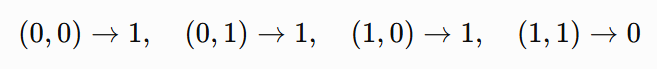

La red debe aprender esos cuatro patrones.

In [9]:
param_NAND, salida_NAND, perdida_NAND = entrenar(
    X,
    Y_NAND,
    epocas=50000,
    eta=0.5,
    semilla=42
)

pred_NAND = (salida_NAND >= 0.5).astype(int)

print("Salida continua NAND:")
print(np.round(salida_NAND, 4))

print("\nSalida clasificada NAND:")
print(pred_NAND)

print("\nSalida esperada:")
print(Y_NAND.astype(int))

Salida continua NAND:
[[0.9985 0.9934 0.9933 0.0114]]

Salida clasificada NAND:
[[1 1 1 0]]

Salida esperada:
[[1 1 1 0]]


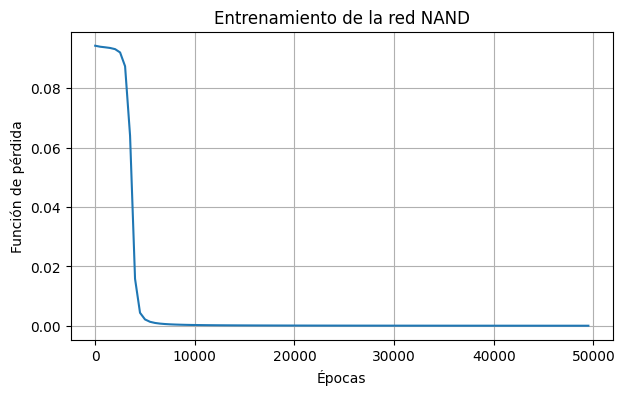

In [10]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(len(perdida_NAND))*500, perdida_NAND)
plt.xlabel("Épocas")
plt.ylabel("Función de pérdida")
plt.title("Entrenamiento de la red NAND")
plt.grid(True)
plt.show()

### Interpretación NAND

Si el entrenamiento converge correctamente, las salidas continuas estarán próximas a:

[1, 1, 1, 0]

Al aplicar un umbral de 0.5 se obtiene exactamente la tabla de verdad de NAND.

# Red 2 — Compuerta XOR

La tabla de verdad de XOR es:

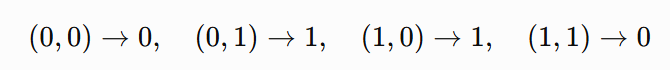

XOR es especialmente importante porque **no puede resolverse con una única neurona lineal**. La presencia de capas ocultas permite aprender una frontera de decisión no lineal.

In [11]:
param_XOR, salida_XOR, perdida_XOR = entrenar(
    X,
    Y_XOR,
    epocas=50000,
    eta=0.5,
    semilla=43
)

pred_XOR = (salida_XOR >= 0.5).astype(int)

print("Salida continua XOR:")
print(np.round(salida_XOR, 4))

print("\nSalida clasificada XOR:")
print(pred_XOR)

print("\nSalida esperada:")
print(Y_XOR.astype(int))

Salida continua XOR:
[[0.0135 0.9889 0.9889 0.0127]]

Salida clasificada XOR:
[[0 1 1 0]]

Salida esperada:
[[0 1 1 0]]


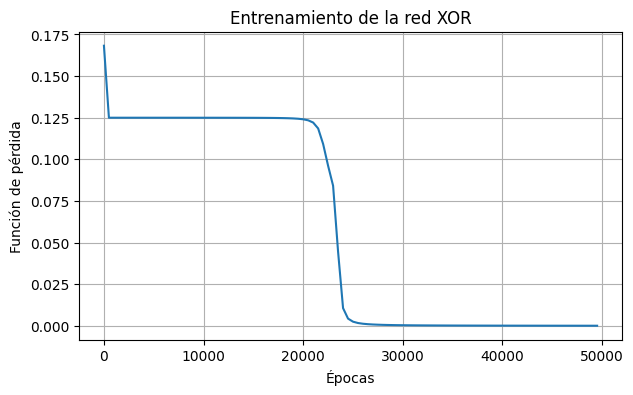

In [12]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(len(perdida_XOR))*500, perdida_XOR)
plt.xlabel("Épocas")
plt.ylabel("Función de pérdida")
plt.title("Entrenamiento de la red XOR")
plt.grid(True)
plt.show()

### Interpretación XOR

Después del entrenamiento, las salidas deben aproximarse a:

[0, 1, 1, 0]

Al usar un umbral de 0.5 se obtiene la clasificación binaria correspondiente a la compuerta XOR.

---

## Conclusión

La red NAND aprende una relación relativamente sencilla, mientras que XOR requiere la capacidad no lineal proporcionada por las capas ocultas. En ambos casos, luego del entrenamiento la salida continua de la red puede convertirse a 0 o 1 usando un umbral de 0.5.